In [10]:
from pyscf import gto, scf
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.operators.tensor_ordering import to_physicist_ordering
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np


# Define molecule, pick basis, get HF solution, form integrals and transform them into Pauli strings

In [11]:

# 1. Molecular setup & integrals
mol = gto.M(atom='H 0 0 0; H 0 0 0.74', basis='sto-3g')
nuc_repulsion = mol.energy_nuc()

mf = scf.RHF(mol).run()
C = mf.mo_coeff
h1e_mo = C.T @ mf.get_hcore() @ C
eri_phys = np.einsum('pqrs,pi,qj,rk,sl->ijkl', mol.intor('int2e'), C, C, C, C)

num_spatial = mol.nao_nr()
num_alpha = (mol.nelectron + mol.spin) // 2
num_beta  = (mol.nelectron - mol.spin) // 2

# 2. Hamiltonian construction & mapping
hamiltonian = ElectronicEnergy.from_raw_integrals(
    h1_a=h1e_mo,
    h2_aa=to_physicist_ordering(eri_phys)
)
mapper = JordanWignerMapper()
qubit_op = mapper.map(hamiltonian.second_q_op())


converged SCF energy = -1.11675930739643


# Prepare the HF state, and then add parametrized excitations into the circuit ansatz

In [12]:

# 3. Ansatz & initial state
init_state = HartreeFock(num_spatial, (num_alpha, num_beta), mapper)
# ansatz = UCCSD(mamapper, (num_alpha, num_beta), num_spatial)
ansatz = UCCSD(num_particles=(num_alpha,num_beta), num_spatial_orbitals=num_spatial, qubit_mapper=mapper)
ansatz.initial_state = init_state


# Visualize the circuit

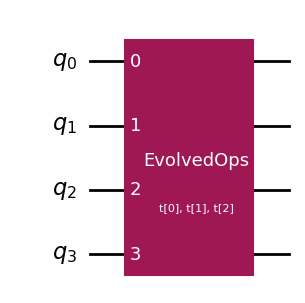

In [13]:
ansatz.draw(output="mpl")

# Decompose one level down and visualize
The first part is preparing the HF state
The next two blocks are single excitations
The last one is a double excitation

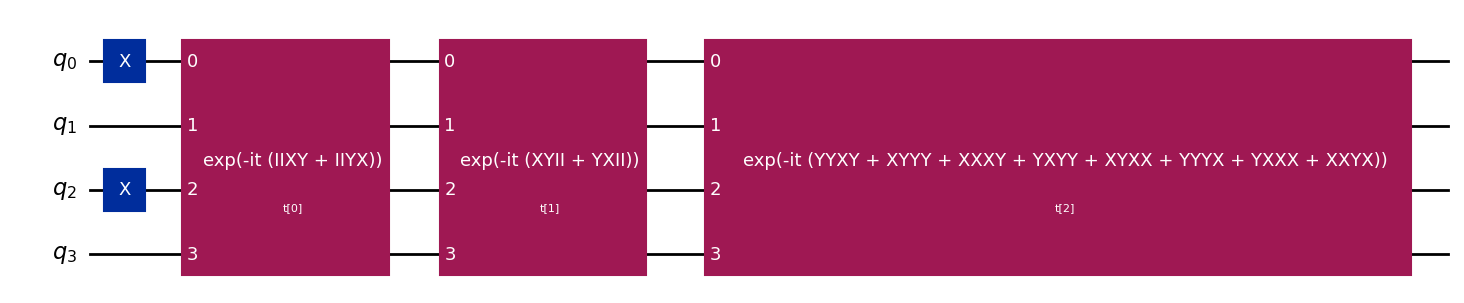

In [14]:
ansatz.decompose(reps=1).draw(output="mpl")

# Decompose more and visualize
Each operation is broken down into gates.
The exponentiation of the excitation operators is done using Trotterization.

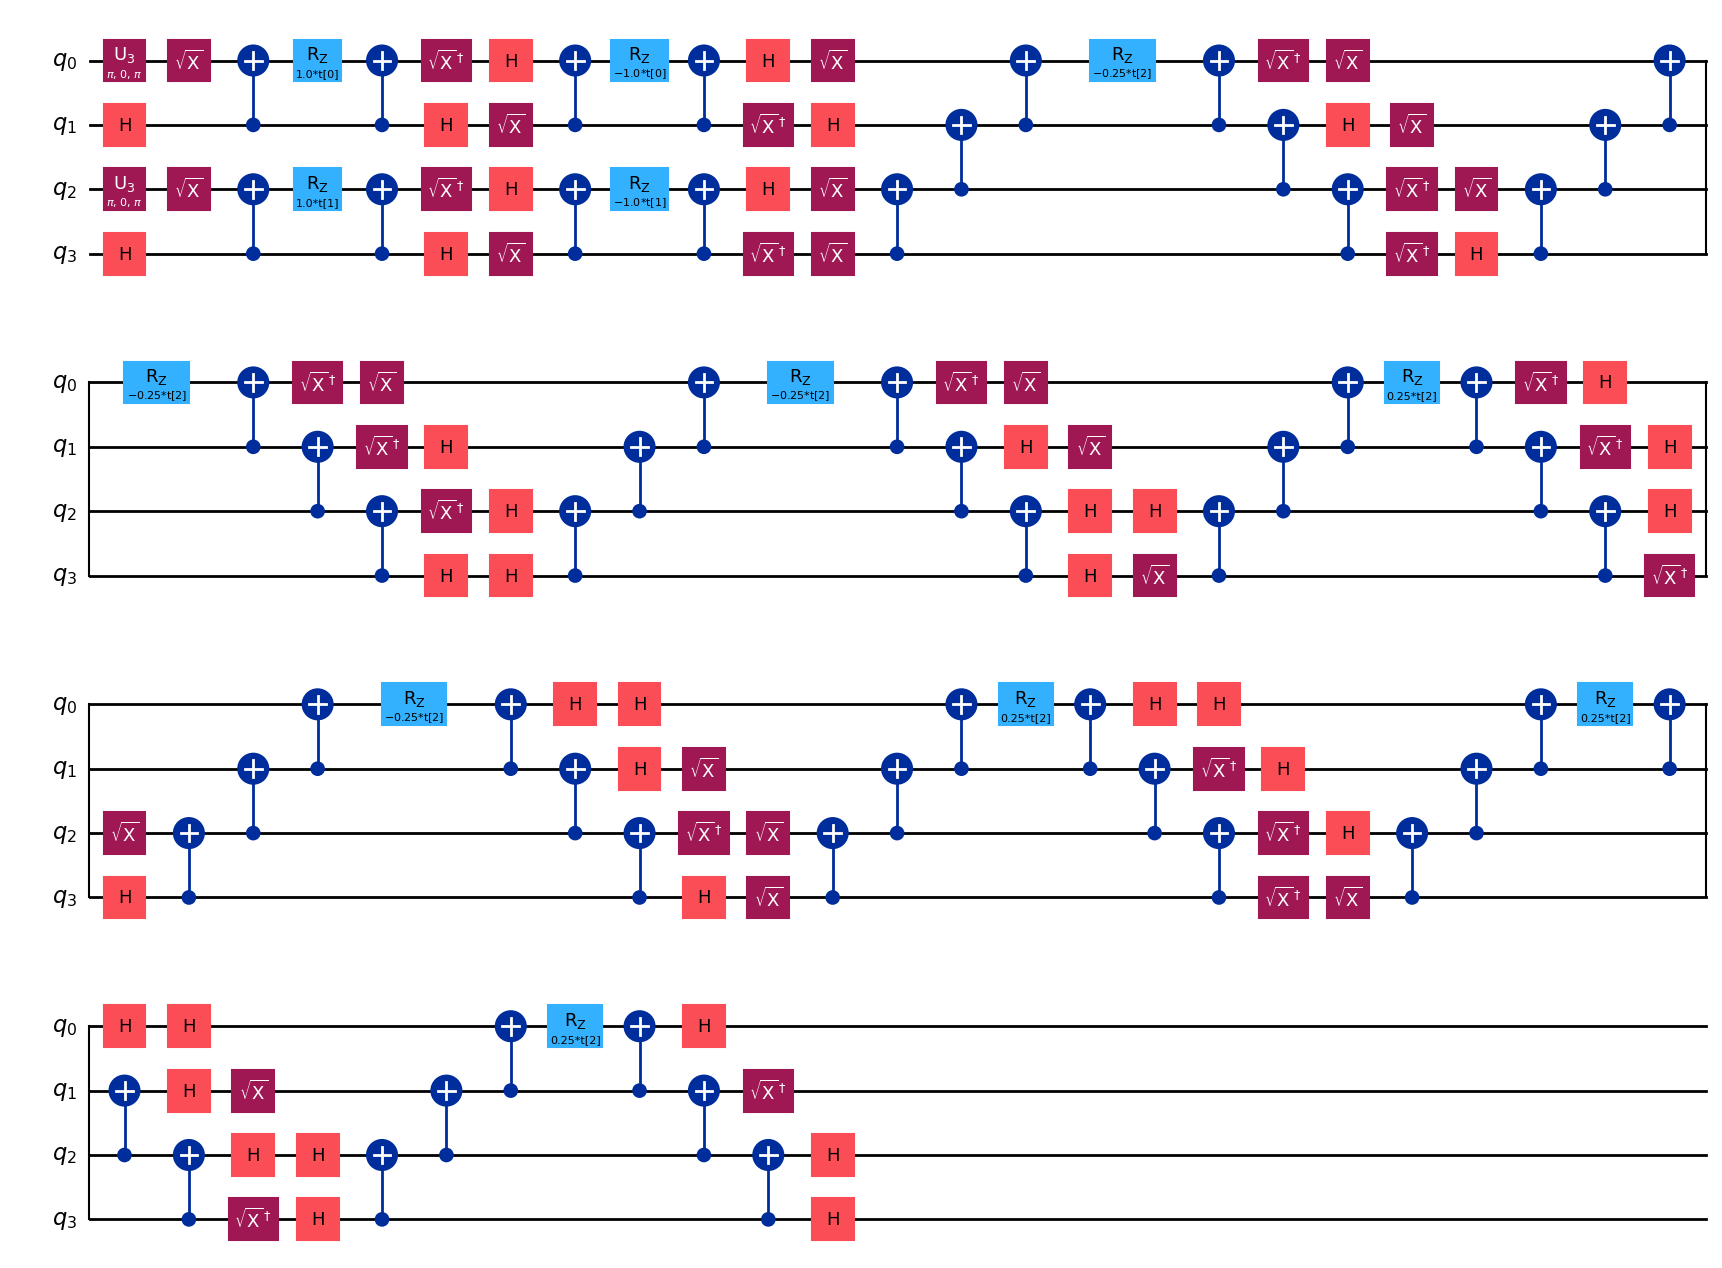

In [15]:
ansatz.decompose(reps=2).draw(output="mpl")

# Optimize the parameters (excitation amplitudes) of the circuit ansatz to minimize energy
Does the final result (energy) match previous PySCF results?

In [16]:

# 4. Scipy optimization loop
estimator = StatevectorEstimator()

def vqe_cost(params):
    bound_circuit = ansatz.assign_parameters(params)
    job = estimator.run([(bound_circuit, qubit_op)])
    return job.result()[0].data.evs

x0 = np.zeros(ansatz.num_parameters)
result = minimize(vqe_cost, x0, method='BFGS', options={'gtol': 1e-6})

print(f"Optimization converged: {result.success}")
print(f"Optimal parameters: {result.x}")
print(f"VQE Ground State Energy: {result.fun + nuc_repulsion} Ha")


Optimization converged: True
Optimal parameters: [ 1.53350715e-07 -7.38697141e-08 -1.12782842e-01]
VQE Ground State Energy: -1.1372838344884735 Ha
